In [1]:
from transformers import AutoModel, AutoTokenizer
from datasets import load_dataset   
import pandas as pd

def map_labels(label):
    return classes[label]


ds = load_dataset("emotion","split")

df_train = pd.DataFrame(ds["train"])
df_val = pd.DataFrame(ds["validation"])
df_test = pd.DataFrame(ds["test"])

classes = ds["train"].features['label'].names

df_train["class_name"] = df_train["label"].apply(map_labels)

df_train.head()

Using the latest cached version of the dataset since emotion couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'split' at C:\Users\abhay\.cache\huggingface\datasets\emotion\split\0.0.0\cab853a1dbdf4c42c2b3ef2173804746df8825fe (last modified on Fri May 29 10:34:18 2026).


,text,label,class_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


In [2]:
classes

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [3]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

## using max_length and padding as 128 due to gpu ram out of memory 

In [4]:
def tokenize(batch):
    res = tokenizer(batch["text"],padding = "max_length",max_length=128,truncation=True)
    return res

In [5]:
tokenize(ds["train"][:10])

{'input_ids': [[101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 10047, 9775, 1037, 3371, 2000, 2695, 1045, 2514, 20505, 3308, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

### mapping of dataset with tokenize function to encode text to numbers

In [6]:
emotions_encoded = ds.map(tokenize,batch_size=True,batched=None)
emotions_encoded

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [7]:
print(emotions_encoded["train"][:5])

{'text': ['i didnt feel humiliated', 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake', 'im grabbing a minute to post i feel greedy wrong', 'i am ever feeling nostalgic about the fireplace i will know that it is still on the property', 'i am feeling grouchy'], 'label': [0, 0, 3, 2, 3], 'input_ids': [[101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [44]:
model_name

'distilbert-base-uncased'

In [9]:
from transformers import AutoModelForSequenceClassification

batch_size = 128
num_labels = len(classes)
device = "cuda"
model = AutoModelForSequenceClassification.from_pretrained(model_name,num_labels = num_labels).to(device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [48]:
from transformers import TrainingArguments, Trainer

In [49]:
model_name = "distillbert_fine_tuned"

In [52]:
import torch

text = "I am angry today"

inputs = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    padding=True
).to(device)

with torch.no_grad():
    outputs = model(**inputs)

predicted_class = torch.argmax(outputs.logits, dim=1).item()

print(classes[predicted_class])

surprise


In [59]:
model

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [60]:
for params in model.parameters():
    params.requires_grad = False

## freeze all layer but unfreeze some of last 4 layer of transformer, preclassifier and classifier

In [93]:

for params in model.distilbert.transformer.layer[-4:].parameters():
    params.requires_grad = True
for params in model.pre_classifier.parameters():
    params.requires_grad = True

for params in model.classifier.parameters():
    params.requires_grad = True

## total and trainable parameter after freezing some layers

In [94]:
trainable  = sum([p.numel() for p in model.parameters() if p.requires_grad])
total  = sum([p.numel() for p in model.parameters()])
print(trainable,total)                 

28946694 66958086


## setup training arguments 

In [95]:
training_args = TrainingArguments(output_dir = f"../model/{model_name}",
                                 num_train_epochs=1,
                                 learning_rate = 1e-5,
                                 per_device_train_batch_size= batch_size,
                                 per_device_eval_batch_size = batch_size,
                                  weight_decay=0.01,
                                  eval_strategy = 'epoch',
                                  disable_tqdm=False)

## evaluation metrics as f1_score

In [70]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(pred):
  labels = pred.label_ids
  preds = pred.predictions.argmax(-1)
  f1 = f1_score(labels, preds, average='weighted')
  acc = accuracy_score(labels, preds)
  return {"accuracy": acc, "f1": f1}


In [96]:
trainer = Trainer(model=model, args=training_args,
                  compute_metrics=compute_metrics,
                  train_dataset=emotions_encoded['train'],
                  eval_dataset=emotions_encoded['validation'],
                  )

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.254696,0.917000,0.917157


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=125, training_loss=0.2532452392578125, metrics={'train_runtime': 586.8551, 'train_samples_per_second': 27.264, 'train_steps_per_second': 0.213, 'total_flos': 529907392512000.0, 'train_loss': 0.2532452392578125, 'epoch': 1.0})

In [98]:
prediction = trainer.predict(emotions_encoded["test"])
prediction.metrics

{'test_loss': 0.25046229362487793,
 'test_accuracy': 0.9075,
 'test_f1': 0.9077574584826383,
 'test_runtime': 30.5109,
 'test_samples_per_second': 65.55,
 'test_steps_per_second': 0.524}

In [99]:
y_pred = prediction.predictions.argmax(axis = 1)
y_true = emotions_encoded["test"][:]["label"]

In [100]:
y_pred[:10],y_true[:10]

(array([0, 0, 0, 1, 0, 4, 3, 0, 1, 3], dtype=int64),
 [0, 0, 0, 1, 0, 4, 3, 1, 1, 3])

In [101]:
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay

In [102]:
report = classification_report(y_true,y_pred,target_names=classes)
print(report)

              precision    recall  f1-score   support

     sadness       0.95      0.94      0.95       581
         joy       0.93      0.93      0.93       695
        love       0.78      0.81      0.79       159
       anger       0.90      0.92      0.91       275
        fear       0.89      0.86      0.87       224
    surprise       0.69      0.71      0.70        66

    accuracy                           0.91      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.91      0.91      0.91      2000



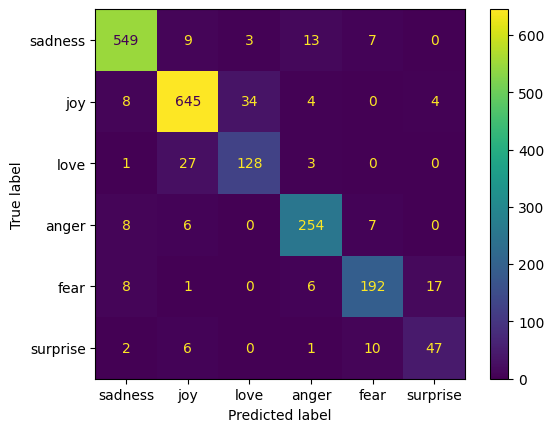

In [103]:
con_matrix = confusion_matrix(y_true,y_pred)
ConfusionMatrixDisplay(con_matrix,display_labels=classes).plot()

In [122]:
sentence = "i am very excited"
tokens = tokenizer(sentence,return_tensors= "pt",padding = "max_length",max_length=128,truncation=True).to(device)

out = model(**tokens)

In [123]:
out

SequenceClassifierOutput(loss=None, logits=tensor([[-1.0473,  4.0829, -1.2934, -0.9261, -1.0418, -1.5225]],
       device='cuda:0', grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)

In [124]:
classes[out.logits.argmax()]

'joy'